## Aravind's Contribution

## In the previous assignment we did the pre-processing but the model were not able to predict the sentences properly hence we again did the preprocessing

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('sentiment_data.csv', encoding='latin1')

In [3]:
# View first few rows
df.head()

,Tweet,Sentiment
0,@_angelica_toy Happy Anniversary!!!....The Day...,Mild_Pos
1,@McfarlaneGlenda Happy Anniversary!!!....The D...,Mild_Pos
2,@thevivafrei @JustinTrudeau Happy Anniversary!...,Mild_Pos
3,@NChartierET Happy Anniversary!!!....The Day t...,Mild_Pos
4,@tabithapeters05 Happy Anniversary!!!....The D...,Mild_Pos


In [4]:
# View the shape and column names
print("Shape of dataset:", df.shape)
print("\nColumn names:", df.columns.tolist())

Shape of dataset: (451332, 2)

Column names: ['Tweet', 'Sentiment']


In [5]:
# Display the first 5 rows
print("\nSample data:")
print(df.head())


Sample data:
                                               Tweet Sentiment
0  @_angelica_toy Happy Anniversary!!!....The Day...  Mild_Pos
1  @McfarlaneGlenda Happy Anniversary!!!....The D...  Mild_Pos
2  @thevivafrei @JustinTrudeau Happy Anniversary!...  Mild_Pos
3  @NChartierET Happy Anniversary!!!....The Day t...  Mild_Pos
4  @tabithapeters05 Happy Anniversary!!!....The D...  Mild_Pos


In [6]:
# Check for null values
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Tweet        1
Sentiment    0
dtype: int64


In [7]:
# Check unique values in sentiment column 
if 'sentiment' in df.columns:
    print("\nSentiment value counts:")
    print(df['sentiment'].value_counts())

##  Clean and Relabel Sentiment Classes

In [10]:
# Drop the one row with missing tweet
df = df.dropna(subset=['Tweet'])

# Map detailed sentiment to 3 broad classes
Sentiment_map = {
    'Strong_Pos': 'Positive',
    'Mild_Pos': 'Positive',
    'Neutral': 'Neutral',
    'Mild_Neg': 'Negative',
    'Strong_Neg': 'Negative'
}
df['Sentiment'] = df['Sentiment'].map(sentiment_map)

## Split Raw Text and Label Before Cleaning or Vectorizing to avoid data leakage

In [12]:
from sklearn.model_selection import train_test_split

# Split BEFORE any vectorization or TF-IDF
X_raw = df['Tweet']
y = df['Sentiment']
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42)

In [13]:
import numpy as np
import re
import emoji
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [14]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [15]:
slang_dict = {
    "u": "you",
    "ur": "your",
    "btw": "by the way",
    "idk": "i do not know",
    "omg": "oh my god",
    "brb": "be right back",
    "lol": "laughing out loud",
    "afaik": "as far as i know",
    "bff": "best friends forever",
    "bday": "birthday",
    "bc": "because",
    "bbl": "be back later",
    "bfn": "bye for now",
    "bts": "behind the scenes",
    "cu": "see you",
    "cya": "see you",
    "dm": "direct message",
    "fb": "facebook",
    "fomo": "fear of missing out",
    "ftw": "for the win",
    "fyi": "for your information",
    "gg": "good game",
    "gr8": "great",
    "gtg": "got to go",
    "hbu": "how about you",
    "hmu": "hit me up",
    "hru": "how are you",
    "icymi": "in case you missed it",
    "idc": "i do not care",
    "ikr": "i know right",
    "ily": "i love you",
    "imo": "in my opinion",
    "imho": "in my humble opinion",
    "irl": "in real life",
    "jk": "just kidding",
    "l8r": "later",
    "lmao": "laughing my ass off",
    "lmk": "let me know",
    "lms": "like my status",
    "nbd": "no big deal",
    "nm": "not much",
    "np": "no problem",
    "nvm": "never mind",
    "omfg": "oh my freaking god",
    "omw": "on my way",
    "ppl": "people",
    "rofl": "rolling on the floor laughing",
    "smh": "shaking my head",
    "snap": "snapchat",
    "srly": "seriously",
    "sup": "what's up",
    "tba": "to be announced",
    "tbd": "to be decided",
    "tfw": "that feeling when",
    "thx": "thanks",
    "tmi": "too much information",
    "ttyl": "talk to you later",
    "tbh": "to be honest",
    "ty": "thank you",
    "vlog": "video blog",
    "wbu": "what about you",
    "wyd": "what are you doing",
    "wym": "what you mean",
    "wya": "where you at",
    "wth": "what the heck",
    "wtf": "what the fudge",
    "xoxo": "hugs and kisses",
    "ya": "you",
    "yolo": "you only live once",
    "yw": "you are welcome",
    "zomg": "oh my god (emphatic)",
    "ikr": "i know right",
    "bruh": "bro",
    "bae": "before anyone else",
    "roflmao": "rolling on the floor laughing my ass off",
    "tysm": "thank you so much",
    "grats": "congratulations",
    "congrats": "congratulations",
    "ig": "instagram",
    "twt": "twitter",
    "dm me": "direct message me",
    "bffl": "best friends for life",
    "smol": "small and cute",
    "stan": "super fan",
    "salty": "bitter or upset",
    "ghost": "suddenly ignore someone",
    "sus": "suspicious",
    "noob": "newbie",
    "flex": "show off",
    "cap": "lie",
    "no cap": "no lie",
    "lowkey": "quietly or secretly",
    "highkey": "openly or obviously",
    "snatched": "stylish or on point",
    "v": "very",
    "lit": "awesome or exciting",
    "slay": "do very well",
    "mood": "relatable feeling",
    "sksksk": "laughing or expressing emotion",
    "and i oop": "when something surprising happens"
}

In [16]:
abbrev_dict = {
    "dept": "department",
    "hrs": "hours",
    "asap": "as soon as possible",
    "min": "minutes",
    "est": "estimated",
    "hr": "human resources",
    "appt": "appointment",
    "qty": "quantity",
    "mgr": "manager",
    "sec": "second",
    "avg": "average",
    "temp": "temperature",
    "conf": "conference",
    "dist": "distance",
    "info": "information",
    "misc": "miscellaneous",
    "max": "maximum",
    "yr": "year",
    "bldg": "building",
    "mtg": "meeting",
    "vol": "volume",
    "eqpt": "equipment",
    "cust": "customer",
    "prod": "product",
    "cat": "category",
    "req": "requirement",
    "stat": "statistic",
    "subj": "subject",
    "tel": "telephone",
    "mfg": "manufacturing",
    "tech": "technology",
    "trans": "transport",
    "util": "utility",
    "edu": "education",
    "med": "medical",
    "eco": "economic",
    "fin": "finance",
    "inv": "investment",
    "mkt": "market",
    "opp": "opportunity",
    "proj": "project",
    "rep": "report",
    "res": "resource",
    "ret": "retail",
    "sched": "schedule",
    "strat": "strategy",
    "syst": "system",
    "transp": "transportation",
    "val": "value",
    "ven": "vendor",
    "whse": "warehouse",
    "yrs": "years",
    "wk": "week",
    "excl": "excluding",
    "incl": "including",
    "adj": "adjustment",
    "bal": "balance",
    "cred": "credit",
    "deb": "debit",
    "estmt": "estimate",
    "finl": "final",
    "int": "interest",
    "invn": "inventory",
    "payt": "payment",
    "pur": "purchase",
    "rcpt": "receipt",
    "rem": "remittance",
    "stmt": "statement",
    "acct": "account",
    "amt": "amount",
    "bkg": "booking",
    "capex": "capital expenditure",
    "opex": "operational expenditure",
    "roi": "return on investment",
    "faq": "frequently asked questions",
    "poc": "point of contact",
    "kpi": "key performance indicator",
    "sla": "service level agreement",
    "rfp": "request for proposal",
    "rfq": "request for quotation",
    "eta": "estimated time of arrival",
    "pfa": "please find attached",
    "eod": "end of day",
    "cob": "close of business",
    "tbd": "to be decided",
    "tba": "to be announced",
    "fyi": "for your information",
    "imo": "in my opinion",
    "tl;dr": "too long; didn’t read",
    "wip": "work in progress",
    "eom": "end of message",
    "fob": "free on board",
    "ppt": "powerpoint",
    "doc": "document",
    "img": "image",
    "conf.": "conference",
    "docx": "document file",
    "xls": "excel spreadsheet",
    "csv": "comma-separated values",
    "pdf": "portable document format"
}

In [17]:
negation_words = {
    "not", "no", "never", "none", "cannot", "didn't", "won't",
    "can't", "isn't", "wasn't", "aren't", "don't", "doesn't", "shouldn't",
    "wouldn't", "couldn't", "haven't", "hasn't", "hadn't", "neither", "nor",
    "nothing", "nowhere", "nobody", "ain't", "without", "barely", "hardly",
    "scarcely", "refuse", "denied", "doubt", "lack", "miss", "fail", "nonexistent",
    "prohibited", "forbidden", "excluded", "banned", "neglected", "withheld",
    "absent", "disallow", "ineffective", "void", "incomplete", "unavailable",
    "undo", "disagree", "disprove", "unsuccessful", "disable", "unacceptable",
    "noncompliant", "untrue", "unwanted", "unable", "unfit", "uncertain",
    "unconfirmed", "unreachable", "unreal", "unsure", "ineligible", "disqualified",
    "dysfunctional", "rejected", "objection", "veto", "renounce", "avoid",
    "cancel", "decline", "abstain", "disconnect", "opposed", "antithesis",
    "negate", "deny", "reverse", "seldom", "restrict", "oppose", "revoke",
    "contradict", "contrary", "inhibit", "hinder", "fail to", "did not",
    "will not", "does not", "do not", "has not", "have not", "had not"
}

negation_suffix = "_NEG"

## Regex Handling

In [18]:
def apply_regex(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^A-Za-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def remove_emojis(text):
    return emoji.replace_emoji(text, replace='')

def handle_slang(text):
    words = text.split()
    return ' '.join([slang_dict.get(w, w) for w in words])

def handle_abbrev(text):
    words = text.split()
    return ' '.join([abbrev_dict.get(w, w) for w in words])

def handle_negation(text):
    tokens = word_tokenize(text)
    result = []
    negated = False
    for word in tokens:
        if word.lower() in negation_words:
            negated = True
            result.append(word)
        elif negated:
            result.append(word + negation_suffix)
        else:
            result.append(word)
    return ' '.join(result)

def final_clean(text):
    text = text.lower()
    text = apply_regex(text)
    text = remove_emojis(text)
    text = handle_slang(text)
    text = handle_abbrev(text)
    text = handle_negation(text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)

## Applying cleaning ONLY AFTER SPLIT to avoid data leakage

In [20]:
X_train_clean = X_train_raw.apply(final_clean)
X_test_clean = X_test_raw.apply(final_clean)

# Combine for export and future modeling
cleaned_train_df = pd.DataFrame({
    'tweet': X_train_raw,
    'clean_tweet': X_train_clean,
    'sentiment': y_train
}).reset_index(drop=True)

cleaned_test_df = pd.DataFrame({
    'tweet': X_test_raw,
    'clean_tweet': X_test_clean,
    'sentiment': y_test
}).reset_index(drop=True)

### Preview cleaned 

In [21]:
print("Sample cleaned training data:")
print(cleaned_train_df.head())

Sample cleaned training data:
                                               tweet  \
0  @michaelcoren Are you near the convoy of freedom?   
1  @wo96729803 I hear at least half of the 'freed...   
2  Ottawaâs interim police chief Steve Bell war...   
3  @DuaneDawson6 @thereds8 Great comparison re: i...   
4  @EvanLSolomon @fordnation @JustinTrudeau Can y...   

                                         clean_tweet sentiment  
0                                near convoy freedom  Positive  
1  hear least half freedom convoy magats south bo...  Positive  
2  ottawa interim police chief steve bell warned ...   Neutral  
3  great comparison invocation war measure act fl...  Negative  
4  trust prime minister slander decent blue colla...  Positive  


## Save cleaned output

In [22]:
cleaned_train_df.to_csv("cleaned_train.csv", index=False)
cleaned_test_df.to_csv("cleaned_test.csv", index=False)

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load preprocessed data
train_df = pd.read_csv('cleaned_train.csv')
test_df = pd.read_csv('cleaned_test.csv')

C:\Users\User\AppData\Local\Temp\ipykernel_19136\4261816367.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='sentiment', order=train_df['sentiment'].value_counts().index, palette="Set2")


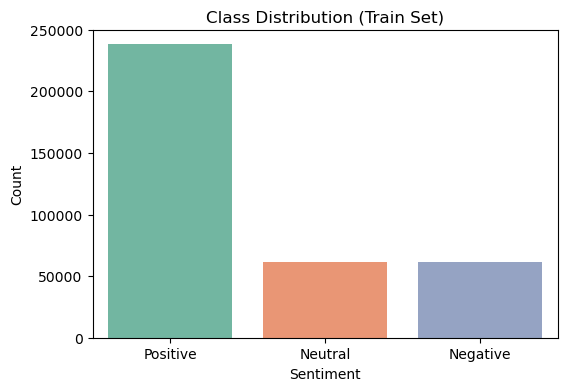

Train Class Counts:
 sentiment
Positive    238096
Neutral      61657
Negative     61311
Name: count, dtype: int64


In [3]:
# Plot class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x='sentiment', order=train_df['sentiment'].value_counts().index, palette="Set2")
plt.title("Class Distribution (Train Set)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

# Print value counts
print("Train Class Counts:\n", train_df['sentiment'].value_counts())

C:\Users\User\AppData\Local\Temp\ipykernel_19136\1114300848.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_balanced, x='sentiment', palette='Set2')


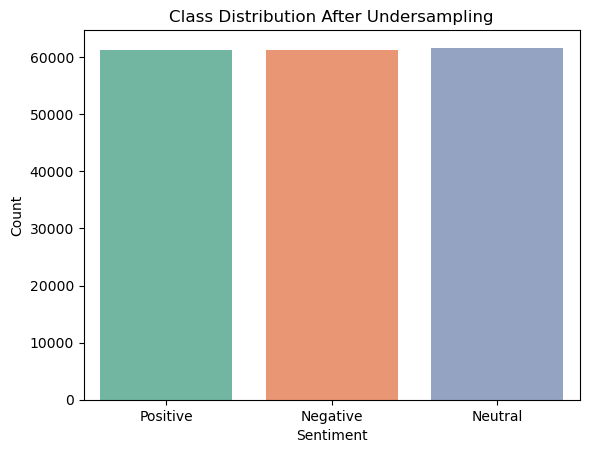

Balanced Class Counts:
 sentiment
Neutral     61657
Positive    61311
Negative    61311
Name: count, dtype: int64


In [4]:
from sklearn.utils import resample
import seaborn as sns
import matplotlib.pyplot as plt

# Separate each class
positive = train_df[train_df['sentiment'] == 'Positive']
neutral  = train_df[train_df['sentiment'] == 'Neutral']
negative = train_df[train_df['sentiment'] == 'Negative']

# Undersample majority class to minority size
target_size = min(len(neutral), len(negative))

positive_down = resample(positive, replace=False, n_samples=target_size, random_state=42)

# Combine to create a balanced training set
train_balanced = pd.concat([positive_down, neutral, negative])
train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Visualize balanced class counts
sns.countplot(data=train_balanced, x='sentiment', palette='Set2')
plt.title("Class Distribution After Undersampling")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

# Confirm counts
print("Balanced Class Counts:\n", train_balanced['sentiment'].value_counts())

In [5]:
train_balanced.to_csv("cleaned_train_balanced.csv", index=False)

### Tweet Length Distribution

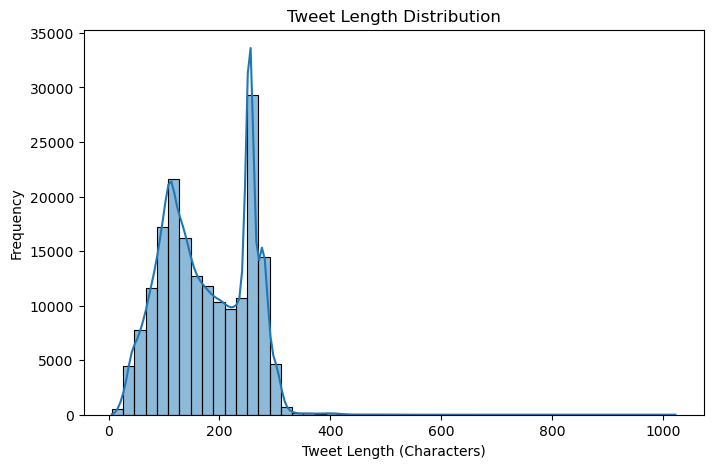

In [6]:
train_balanced['tweet_length'] = train_balanced['tweet'].apply(len)

plt.figure(figsize=(8, 5))
sns.histplot(data=train_balanced, x='tweet_length', bins=50, kde=True)
plt.title("Tweet Length Distribution")
plt.xlabel("Tweet Length (Characters)")
plt.ylabel("Frequency")
plt.show()

### Tweet length by sentiment

C:\Users\User\AppData\Local\Temp\ipykernel_19136\2916202995.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_balanced, x='sentiment', y='tweet_length', palette='Set3')


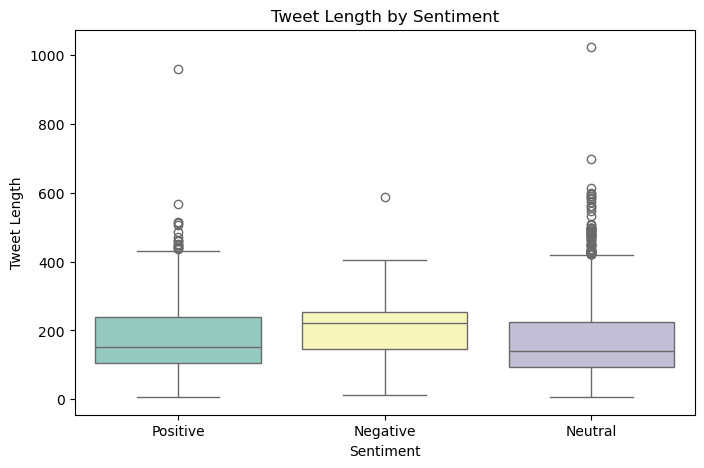

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=train_balanced, x='sentiment', y='tweet_length', palette='Set3')
plt.title("Tweet Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Tweet Length")
plt.show()

### Words count per tweet

C:\Users\User\AppData\Local\Temp\ipykernel_19136\1722919865.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=train_balanced, x='sentiment', y='word_count', palette='Set2')


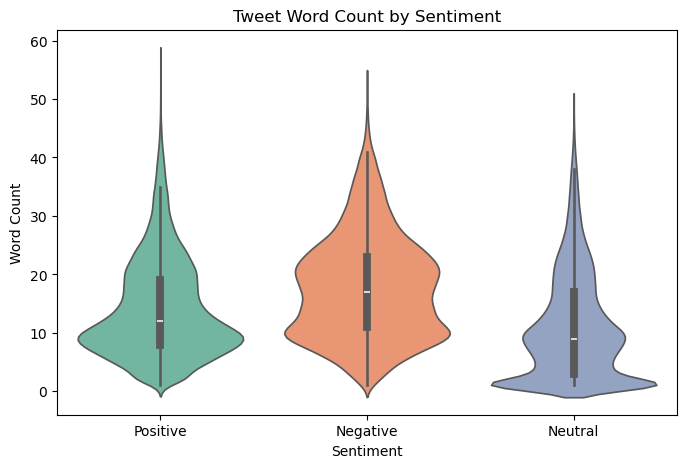


Average Word Count Per Sentiment:
sentiment
Negative    17.82
Neutral     11.11
Positive    14.18
Name: word_count, dtype: float64


In [8]:
train_balanced['word_count'] = train_balanced['clean_tweet'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8, 5))
sns.violinplot(data=train_balanced, x='sentiment', y='word_count', palette='Set2')
plt.title("Tweet Word Count by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Word Count")
plt.show()

# Print average word count per class
print("\nAverage Word Count Per Sentiment:")
print(train_balanced.groupby("sentiment")["word_count"].mean().round(2))

### Top 20 Frequent Words Per Sentiment

In [9]:
# Ensure all clean_tweet entries are strings
train_balanced['clean_tweet'] = train_balanced['clean_tweet'].fillna("").astype(str)

C:\Users\User\AppData\Local\Temp\ipykernel_19136\670384592.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=words_df, x='count', y='word', palette='Set1')


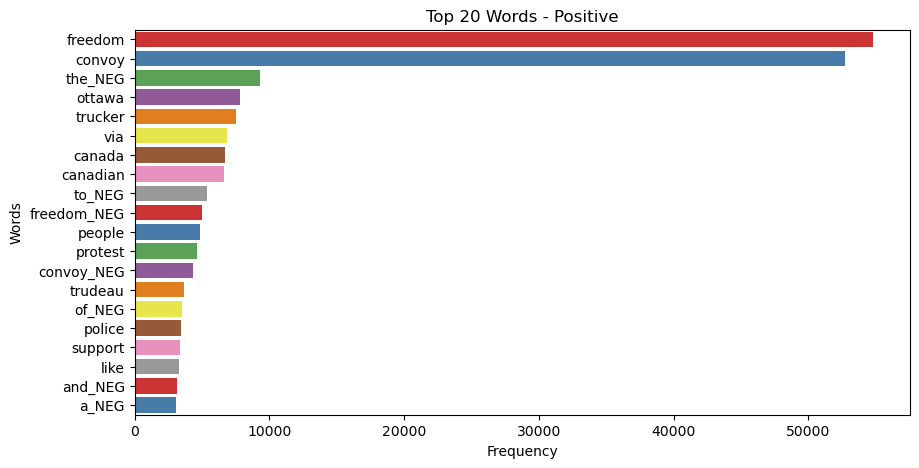

C:\Users\User\AppData\Local\Temp\ipykernel_19136\670384592.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=words_df, x='count', y='word', palette='Set1')


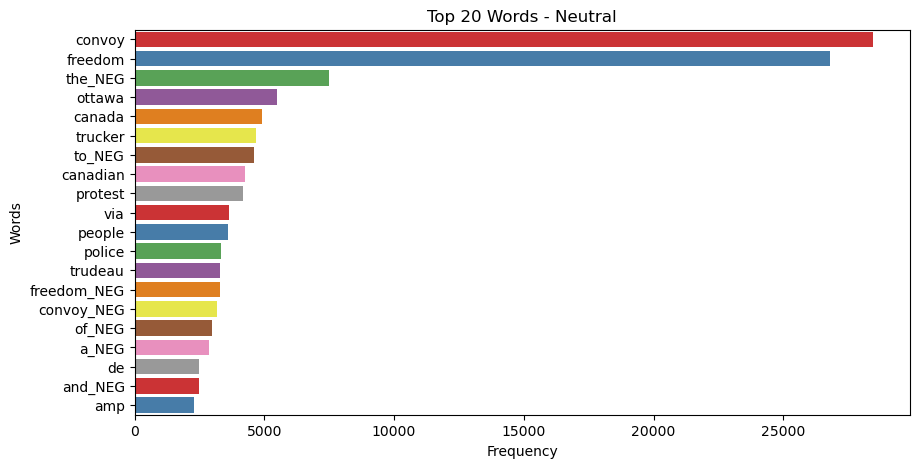

C:\Users\User\AppData\Local\Temp\ipykernel_19136\670384592.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=words_df, x='count', y='word', palette='Set1')


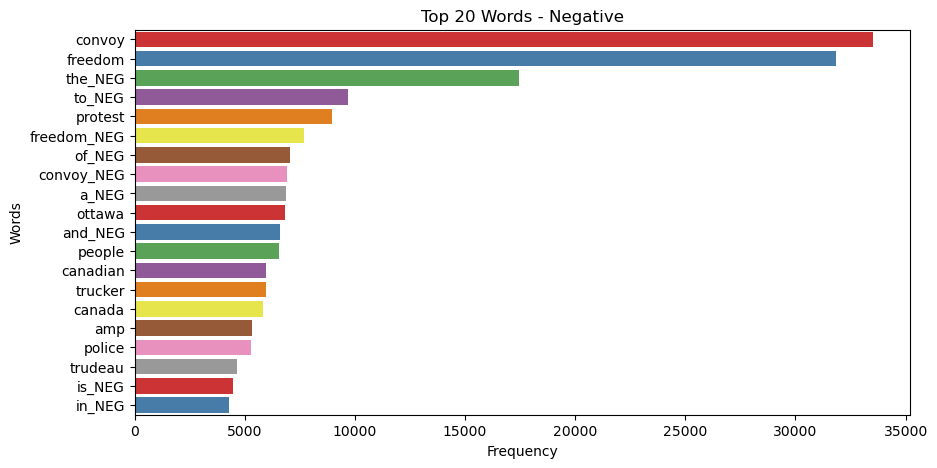

In [10]:
from collections import Counter

def plot_top_words(sentiment_label, top_n=20):
    words = ' '.join(train_balanced[train_balanced['sentiment'] == sentiment_label]['clean_tweet']).split()
    common_words = Counter(words).most_common(top_n)
    words_df = pd.DataFrame(common_words, columns=['word', 'count'])

    plt.figure(figsize=(10, 5))
    sns.barplot(data=words_df, x='count', y='word', palette='Set1')
    plt.title(f"Top {top_n} Words - {sentiment_label}")
    plt.xlabel("Frequency")
    plt.ylabel("Words")
    plt.show()

# Run for each class
plot_top_words('Positive')
plot_top_words('Neutral')
plot_top_words('Negative')

### WordClouds Per Sentiment

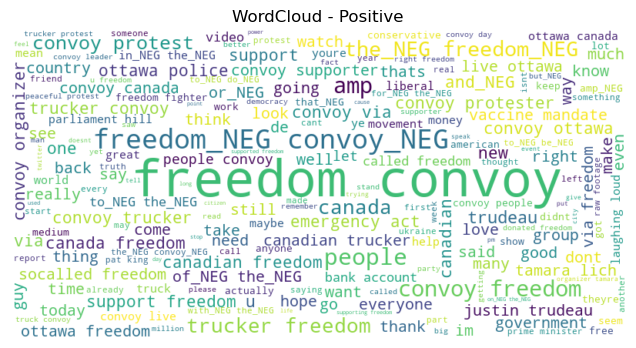

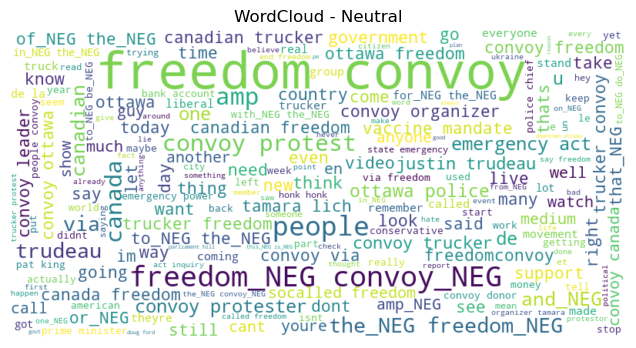

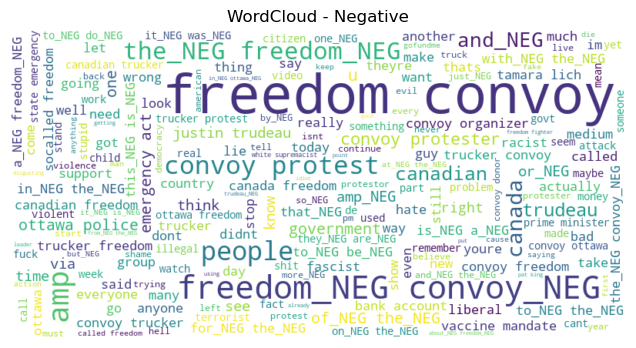

In [12]:
from wordcloud import WordCloud
def generate_wordcloud(df_subset, sentiment_label):
    text = ' '.join(df_subset['clean_tweet'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    
    plt.figure(figsize=(10, 4))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"WordCloud - {sentiment_label}")
    plt.show()

for label in ['Positive', 'Neutral', 'Negative']:
    generate_wordcloud(train_balanced[train_balanced['sentiment'] == label], label)

### Sentiment vs. Average Tweet Length

C:\Users\User\AppData\Local\Temp\ipykernel_19136\1256527991.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_lengths, x='sentiment', y='tweet_length', palette='Set3')


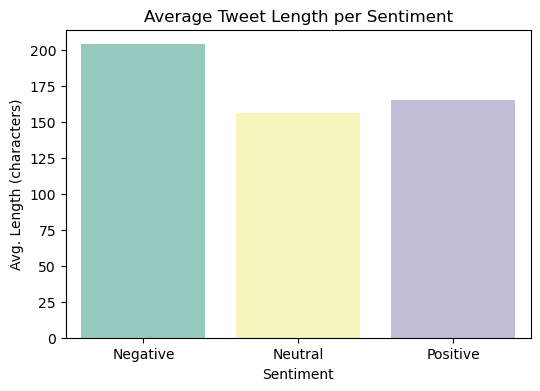

In [13]:
avg_lengths = train_balanced.groupby('sentiment')['tweet_length'].mean().reset_index()

plt.figure(figsize=(6, 4))
sns.barplot(data=avg_lengths, x='sentiment', y='tweet_length', palette='Set3')
plt.title("Average Tweet Length per Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Avg. Length (characters)")
plt.show()

### Distribution of Word Count by Sentiment

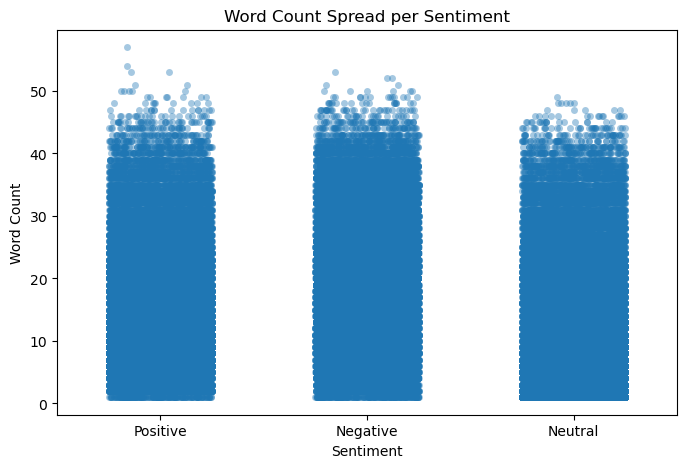

In [14]:
plt.figure(figsize=(8, 5))
sns.stripplot(data=train_balanced, x='sentiment', y='word_count', jitter=0.25, alpha=0.4)
plt.title("Word Count Spread per Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Word Count")
plt.show()

### Top Hashtags by Sentiment

C:\Users\User\AppData\Local\Temp\ipykernel_19136\3362874263.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tag_df, y='hashtag', x='count', palette='muted')


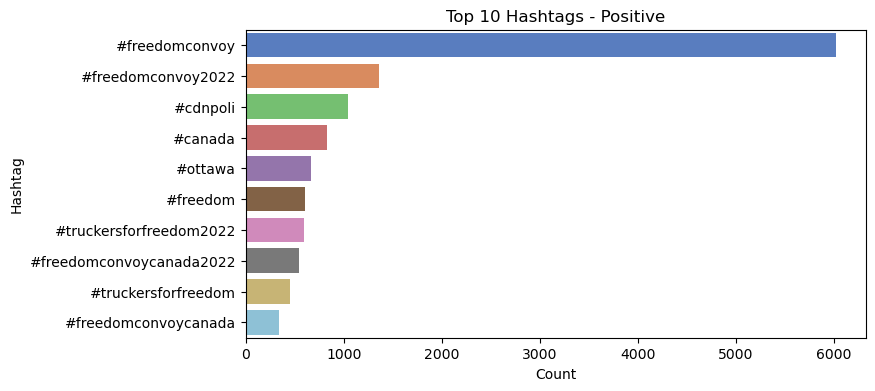

C:\Users\User\AppData\Local\Temp\ipykernel_19136\3362874263.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tag_df, y='hashtag', x='count', palette='muted')


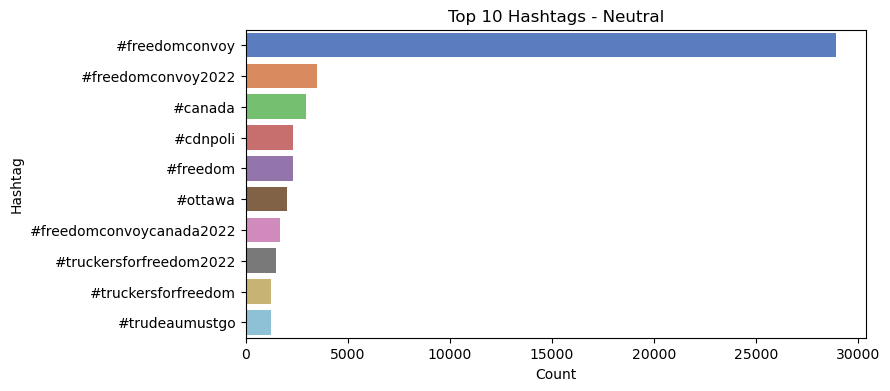

C:\Users\User\AppData\Local\Temp\ipykernel_19136\3362874263.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tag_df, y='hashtag', x='count', palette='muted')


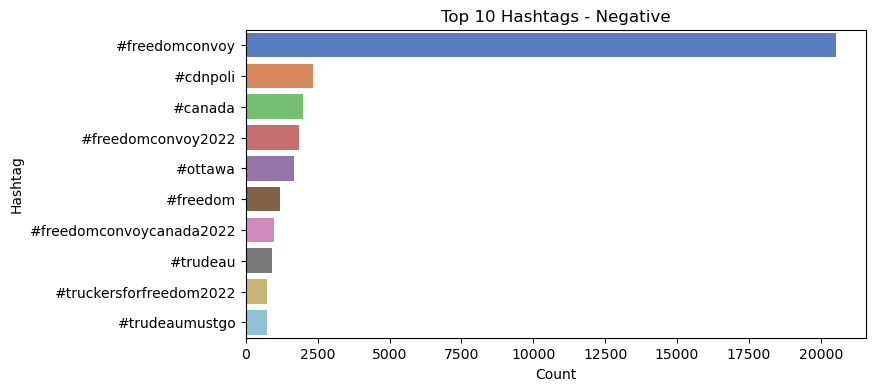

In [15]:
import re
from collections import Counter

def extract_hashtags(text):
    return re.findall(r'#\w+', str(text).lower())

# Add column with hashtags list
train_balanced['hashtags'] = train_balanced['tweet'].apply(extract_hashtags)

# Flatten + count top hashtags per sentiment
def top_hashtags(sentiment, top_n=10):
    tags = train_balanced[train_balanced['sentiment'] == sentiment]['hashtags'].explode()
    common = Counter(tags).most_common(top_n)
    tag_df = pd.DataFrame(common, columns=['hashtag', 'count'])

    plt.figure(figsize=(8, 4))
    sns.barplot(data=tag_df, y='hashtag', x='count', palette='muted')
    plt.title(f"Top {top_n} Hashtags - {sentiment}")
    plt.xlabel("Count")
    plt.ylabel("Hashtag")
    plt.show()

# Run it
top_hashtags('Positive')
top_hashtags('Neutral')
top_hashtags('Negative')

### Sentiment Proportions in a Pie Chart

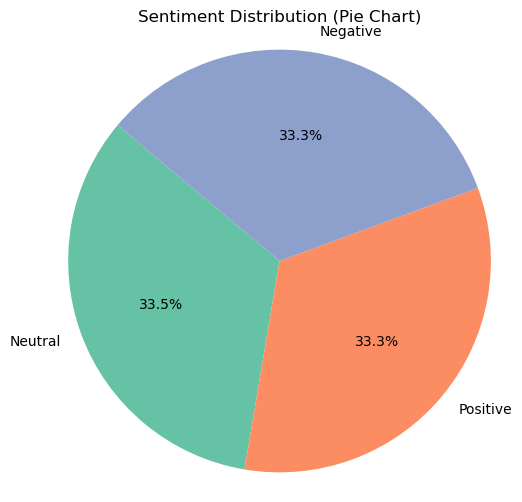

In [16]:
sizes = train_balanced['sentiment'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=sizes.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set2'))
plt.title("Sentiment Distribution (Pie Chart)")
plt.axis('equal')
plt.show()

###  Pairplot

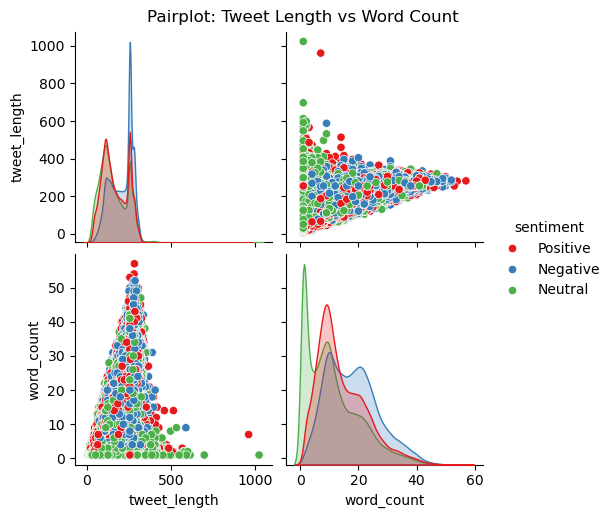

In [17]:
sns.pairplot(train_balanced[['tweet_length', 'word_count', 'sentiment']], hue='sentiment', palette='Set1')
plt.suptitle("Pairplot: Tweet Length vs Word Count", y=1.02)
plt.show()

### Checking Class Separatability

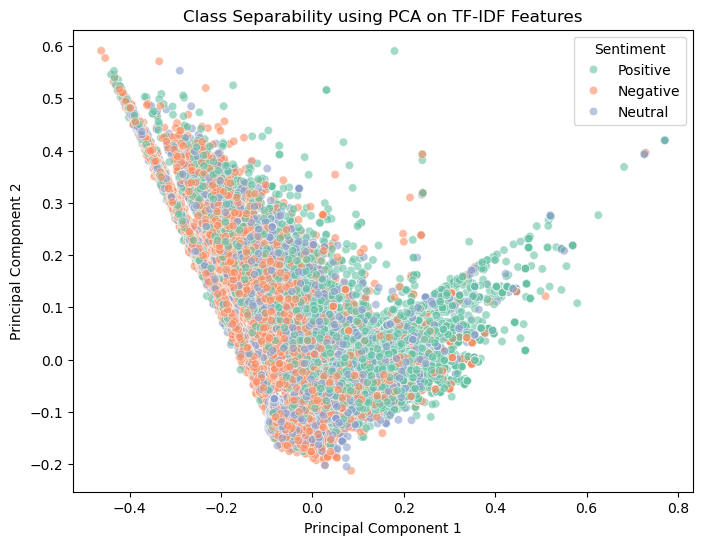

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare input
texts = train_balanced['clean_tweet'].fillna('').astype(str)
labels = train_balanced['sentiment']

# 2. Convert text to TF-IDF vectors
tfidf = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf.fit_transform(texts)

# 3. Apply PCA to reduce to 2 components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_tfidf.toarray())

# 4. Visualize PCA output
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette='Set2', alpha=0.6)
plt.title("Class Separability using PCA on TF-IDF Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Sentiment")
plt.show()

- The plot shows significant class overlap among Positive, Neutral, and Negative tweets.
- Clusters are not clearly separated, which is typical for text data compressed into just 2 PCA components from high-dimensional TF-IDF vectors.
- PCA is linear and focuses on maximizing variance, not necessarily on class separation.

## Feature Engineering

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# 1. Load the balanced data
train_balanced = pd.read_csv("cleaned_train_balanced.csv")

# 2. Prepare text and labels
texts = train_balanced['clean_tweet'].fillna('').astype(str)
labels = train_balanced['sentiment']

# 3. TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf.fit_transform(texts)

# 4. Train Logistic Regression 
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_tfidf, labels)

# 5. Get top features words per class based on weight
feature_names = tfidf.get_feature_names_out()

print("Top 10 Most Influential Features Per Class:\n")
for i, class_label in enumerate(clf.classes_):
    top_indices = clf.coef_[i].argsort()[-10:][::-1]  # Top 10
    top_features = [(feature_names[j], round(clf.coef_[i][j], 3)) for j in top_indices]
    print(f"{class_label}: {top_features[:2]}")  

Top 10 Most Influential Features Per Class:

Negative: [('violence', 3.864), ('kill', 3.861)]
Neutral: [('freedomconvoy', 1.124), ('declares', 1.033)]
Positive: [('freedom', 8.353), ('great', 3.762)]


## Global Interpretability – Top Words per Sentiment

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorize cleaned tweets
texts = train_balanced['clean_tweet'].fillna('').astype(str)
labels = train_balanced['sentiment']

tfidf = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf.fit_transform(texts)

# Train interpretable classifier
clf = LogisticRegression(max_iter=1000)
clf.fit(X_tfidf, labels)

# Feature names
feature_names = tfidf.get_feature_names_out()

# Top 2 features per class (highest positive coefficients)
print("Top 2 TF-IDF Features With Highest Weights Per Class:\n")

for i, class_label in enumerate(clf.classes_):
    top_indices = clf.coef_[i].argsort()[-2:][::-1]  # top 2
    top_features = [(feature_names[j], clf.coef_[i][j]) for j in top_indices]
    print(f"{class_label}: {top_features}")

Top 2 TF-IDF Features With Highest Weights Per Class:

Negative: [('violence', 3.8637534965864035), ('kill', 3.8605343346087855)]
Neutral: [('freedomconvoy', 1.1235166676471686), ('declares', 1.032711991519974)]
Positive: [('freedom', 8.352784665339929), ('great', 3.761839743235271)]


## Local Interpretability with LIME

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

texts = train_balanced['clean_tweet'].fillna('').astype(str)
labels = train_balanced['sentiment']

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf.fit_transform(texts)

# Train Logistic Regression
clf = LogisticRegression(max_iter=1000)
clf.fit(X_tfidf, labels)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [4]:
import lime
import lime.lime_text
from sklearn.pipeline import make_pipeline

# 1. Creating pipeline: LIME needs text -> prediction pipeline
pipeline = make_pipeline(tfidf, clf)

# 2. Initialize LIME explainer
class_names = clf.classes_.tolist()
explainer = lime.lime_text.LimeTextExplainer(class_names=class_names)

# 3. Pick a sample tweet to explain
sample_index = 42  # pick any row index
sample_text = texts.iloc[sample_index]
print(f"Tweet to explain: {sample_text}")
print(f"True label: {labels.iloc[sample_index]}")
print(f"Predicted: {pipeline.predict([sample_text])[0]}")

# 4. Generate explanation
exp = explainer.explain_instance(sample_text, pipeline.predict_proba, num_features=6)

# 5. Display explanation inline
exp.show_in_notebook(text=True)

Tweet to explain: hear understand heavily influenced infiltrated dangerous terrorist declaration necessary response counter real threat possible element
True label: Negative
Predicted: Negative


### LLM Prompts
- First - How do I use regex handling
- Last - How to proceed with lime for the explanation